In [4]:
import os
import warnings
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score, fbeta_score, confusion_matrix

# Suppress specific warning messages
warnings.filterwarnings("ignore", category=FutureWarning)

In [5]:
# Parameter setting
cage_type = 'repSub'
samples = ['C1', 'C2', 'C3', 'N4', 'N5', 'N6', '10M_N1', '10M_N2', '10M_N3', 'groCap_1', 'ProCap_pcr_2']

directory = 'data/epc_repSub_profile/predictions/'
pattern_pos = 'PRIMEloci_pred_all_profiles_subtnorm_pos_EPC_pos_K562_{sample}.bed'
pattern_neg = 'PRIMEloci_pred_all_profiles_subtnorm_neg_EPC_neg_K562_{sample}.bed'

colors = {'C':"#FE8D02", 'C1':"#FE8D02", 'C2':"#FE8D02", 'C3':"#FE8D02", 
          'N':"#FF4425", 'N4':"#FF4425", 'N5':"#FF4425", 'N6':"#FF4425",
          '10M_N1':"#7D62CF", '10M_N2':"#7D62CF", '10M_N3':"#7D62CF", '10M_N':"#7D62CF",
          'groCap_1':"#3D4138", 'ProCap_pcr_2':"#878784"}

In [6]:
def set_score_to_nan_where_sum_count_zero(df):
    """
    Sets 'score' to NaN where 'sum_count' is 0 in the dataframe.
    """
    print("Filtering: Setting 'score' to NaN where 'sum_count' = 0.")
    df['score'] = df.apply(
        lambda row: np.nan if row['sum_count'] == 0 else row['score'],
        axis=1
    )
    return df


def load_and_filter_prediction_data(directory, samples, pattern, y_true, outname):
    """
    Loads BED files for specified samples, applies filtering, splits data into
    'score', 'sum_count', and 'others' dataframes, and checks for column consistency.

    Parameters:
        directory (str): The directory containing the files.
        samples (list): List of sample names in the desired order.
        pattern (str): The pattern to match filenames.
        y_true (int): A uniform label to apply across all rows.

    Returns:
        tuple: DataFrames for scores, sum_counts, and others.
    """
    # Initialize dataframes for scores, sum_counts, and others
    df_scores = pd.DataFrame()
    df_sum_counts = pd.DataFrame()
    df_others = None  # Set to None initially to check consistency

    # Loop through each sample
    for sample in samples:
        # Construct the expected filename pattern
        filename_pattern = pattern.format(sample=sample)

        # Look for the file in the directory that matches the pattern
        for filename in os.listdir(directory):
            if filename_pattern in filename:
                # Construct full file path
                file_path = os.path.join(directory, filename)

                # Read the BED file into a dataframe
                df = pd.read_csv(file_path, sep='\t', header=0)

                # Filter scores based on sum_count
                df = set_score_to_nan_where_sum_count_zero(df)

                # Extract and add score column to `df_scores`
                score_col = df['score'].rename(sample)
                df_scores = pd.concat([df_scores, score_col], axis=1)

                # Extract and add sum_count column to `df_sum_counts`
                sum_count_col = df['sum_count'].rename(sample)
                df_sum_counts = pd.concat([df_sum_counts, sum_count_col], axis=1)

                # Check consistency of other columns and add them to `df_others`
                other_columns = [col for col in df.columns if col not in ['chrom', 'chromStart', 'chromEnd', 'score', 'sum_count', 'name']]
                others_df = df[['chrom', 'chromStart', 'chromEnd'] + other_columns]

                if df_others is None:
                    # Initialize df_others with the first file's content
                    df_others = others_df
                else:
                    # Check consistency of others
                    if not others_df.equals(df_others):
                        raise ValueError(f"Inconsistent 'others' columns in sample {sample}. Stopping execution.")

                break

    # Add uniform label column to scores and sum_count dataframes
    if not df_scores.empty:
        df_scores['y_true'] = y_true
        df_sum_counts['y_true'] = y_true

        # Save the resulting dataframes to BED files (optional)
        df_scores.to_csv(outname+'_score.bed', sep='\t', index=False)
        df_sum_counts.to_csv(outname+'_sumcount.bed', sep='\t', index=False)
        df_others.to_csv(outname+'_position.bed', sep='\t', index=False)

        # Print the resulting dataframes (for verification)
        print("Scores DataFrame:")
        print(df_scores.head())
        print("\nSum Counts DataFrame:")
        print(df_sum_counts.head())
        print("\nPosition DataFrame:")
        print(df_others.head())

    return df_scores, df_sum_counts, df_others

In [7]:
# Process the files and get the dataframes
pos_scores, pos_sum_counts, pos_position = load_and_filter_prediction_data(directory, samples, pattern_pos, y_true=1, outname='repSub_epc_pos')

Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Scores DataFrame:
         C1        C2        C3        N4        N5        N6    10M_N1  \
0  0.799377  0.467952  0.596154  0.632423  0.801303  0.665438  0.473552   
1       NaN       NaN       NaN  0.415209       NaN       NaN       NaN   
2  0.842606  0.638838  0.860361  0.736602  0.704559  0.863999  0.798959   
3  0.823594  0.696666  0.588143  0.853287  0.823908  0.

In [8]:
neg_scores, neg_sum_counts, neg_position = load_and_filter_prediction_data(directory, samples, pattern_neg, y_true=0, outname='repSub_epc_neg')

Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Filtering: Setting 'score' to NaN where 'sum_count' = 0.
Scores DataFrame:
         C1        C2        C3        N4        N5        N6    10M_N1  \
0  0.516463  0.358427  0.461838  0.587138  0.543633  0.507845  0.487781   
1       NaN       NaN       NaN       NaN  0.445794       NaN  0.410080   
2       NaN       NaN       NaN       NaN       NaN       NaN  0.437139   
3  0.437882       NaN       NaN  0.475277  0.463293    

In [9]:
P = len(pos_sum_counts)
N = len(neg_sum_counts)

In [10]:
def plot_count_zero(pos_df_sum_counts,
                    neg_df_sum_counts,
                    samples, colors,
                    P, N, output_pdf):
    # Masking values == 0
    pos_df_sum_counts_mask0 = pos_df_sum_counts[samples] == 0
    neg_df_sum_counts_mask0 = neg_df_sum_counts[samples] == 0

    # Counting zeros
    pos_count = pos_df_sum_counts_mask0.sum(axis=0)
    neg_count = neg_df_sum_counts_mask0.sum(axis=0)

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Plot positive barplot
    sns.barplot(x=pos_count.index, y=pos_count.values, palette=colors, ax=ax1)
    ax1.set_title(f'Data that have COUNT = 0 \n EPC Positive : out of {P}')
    ax1.set_xlabel('Libraries')
    ax1.set_ylabel('Number')
    ax1.set_ylim(0, P)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")

    # Plot negative barplot
    sns.barplot(x=neg_count.index, y=neg_count.values, palette=colors, ax=ax2)
    ax2.set_title(f'Data that have COUNT = 0 \n EPC Negative : out of {N}')
    ax2.set_xlabel('Libraries')
    ax2.set_ylim(0, N)
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")

    plt.tight_layout()

    # Save the figure as a PDF
    plt.savefig(output_pdf)

    # Show the plot
    plt.show()

/var/folders/89/x6thnxv92q1cfnwbkr245ryh0000gn/T/ipykernel_72661/339290017.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha="right")
/var/folders/89/x6thnxv92q1cfnwbkr245ryh0000gn/T/ipykernel_72661/339290017.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha="right")


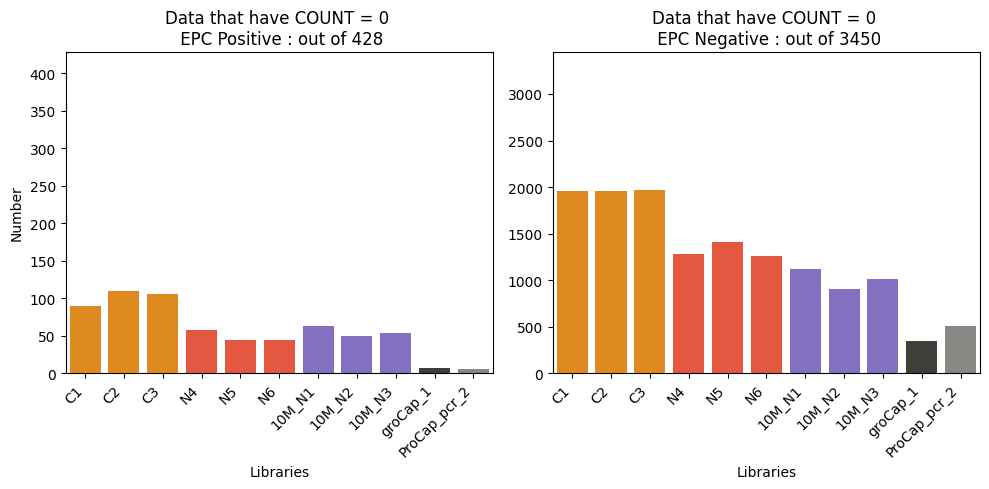

In [11]:
plot_count_zero(pos_sum_counts, neg_sum_counts, samples, colors, P, N, output_pdf='results/repSub_plot_count0.pdf')

In [12]:
def proba_confusion_matrix(df_pos, df_neg, threshold, P, N):

    predpos = df_pos >= threshold
    TP = predpos.sum(axis=0)
    FN = P - TP
    FN_cage = df_pos.isna().sum(axis=0)
    FN_pred = FN - FN_cage

    predneg = df_neg < threshold
    TN_pred = predneg.sum(axis=0)
    TN_cage = df_neg.isna().sum(axis=0)
    TN = TN_pred + TN_cage
    FP = N - TN

    confusion = pd.DataFrame({'Lib': TP.index,
                              'TP': TP,
                              'FN': FN,
                              'TN': TN,
                              'FP': FP,
                              'FN_cage': FN_cage,
                              'FN_pred': FN_pred,
                              'TN_cage': TN_cage,
                              'TN_pred': TN_pred})

    return confusion


def precaision_recall(confusion):
    precision = confusion['TP'] / (confusion['TP'] + confusion['FP'])
    recall = confusion['TP'] / (confusion['TP'] + confusion['FN'])
    df = pd.DataFrame({'precision': precision,
                       'recall': recall})

    return df


def plot_confusion(confusion, P, N, colors, save):

    fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 8))
    axes = axes.flatten()
    ylimit = [P, P, N, N, P, P, N, N]

    for i, column in enumerate(confusion.columns[1:]):
        # Exclude the first column ('Lib')
        sns.barplot(x='Lib', y=column,
                    data=confusion, ax=axes[i],
                    palette=colors)
        axes[i].set_title(f'{column}')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].set_ylim(0, ylimit[i])
    plt.tight_layout()
    if save is not False:
        plt.savefig(save + '.pdf')
    plt.show()


def wrap_cfs_pr_plot(df_pos, df_neg, threshole, P, N, colors, save=False):
    cfs = proba_confusion_matrix(df_pos, df_neg, threshole, P, N)
    pr = precaision_recall(cfs)
    plot_confusion(cfs, P, N, colors, save)
    return cfs, pr

def wrap_pr(df_pos, df_neg, threshole, P, N):
    cfs = proba_confusion_matrix(df_pos, df_neg, threshole, P, N)
    pr = precaision_recall(cfs)
    return pr

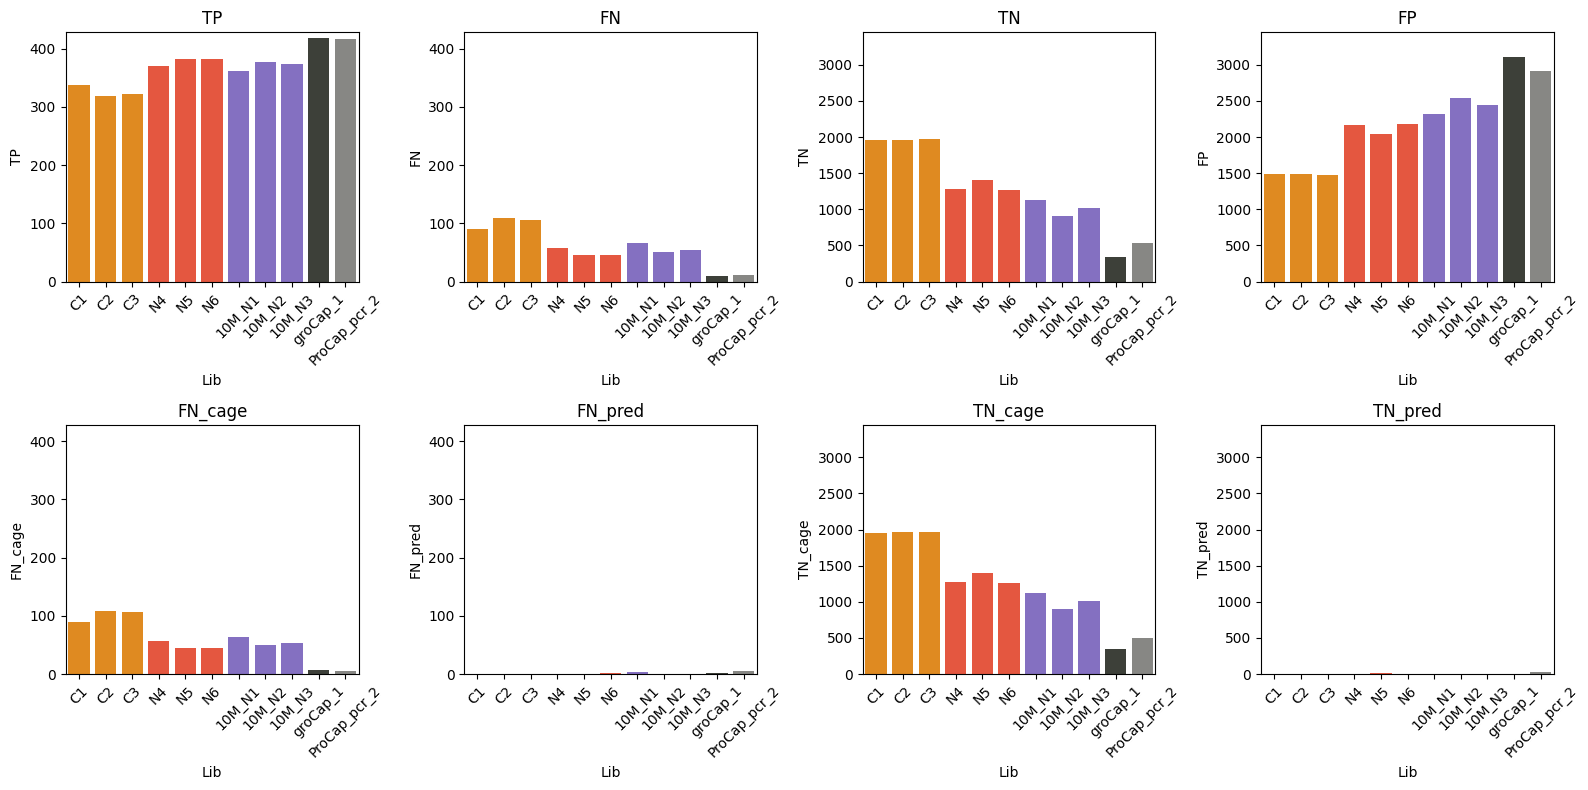

In [13]:
cfs_yproba_030, pr_yproba_030 = wrap_cfs_pr_plot(pos_scores[samples], neg_scores[samples], 0.3, P, N, colors, save='results/repSub_plot_cfs_030')

In [14]:
pr_yproba_030.transpose()

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
precision,0.184052,0.176536,0.178988,0.146467,0.158264,0.148638,0.134723,0.129154,0.132693,0.118966,0.124700
recall,0.787383,0.745327,0.752336,0.866822,0.894860,0.892523,0.845794,0.880841,0.871495,0.978972,0.971963


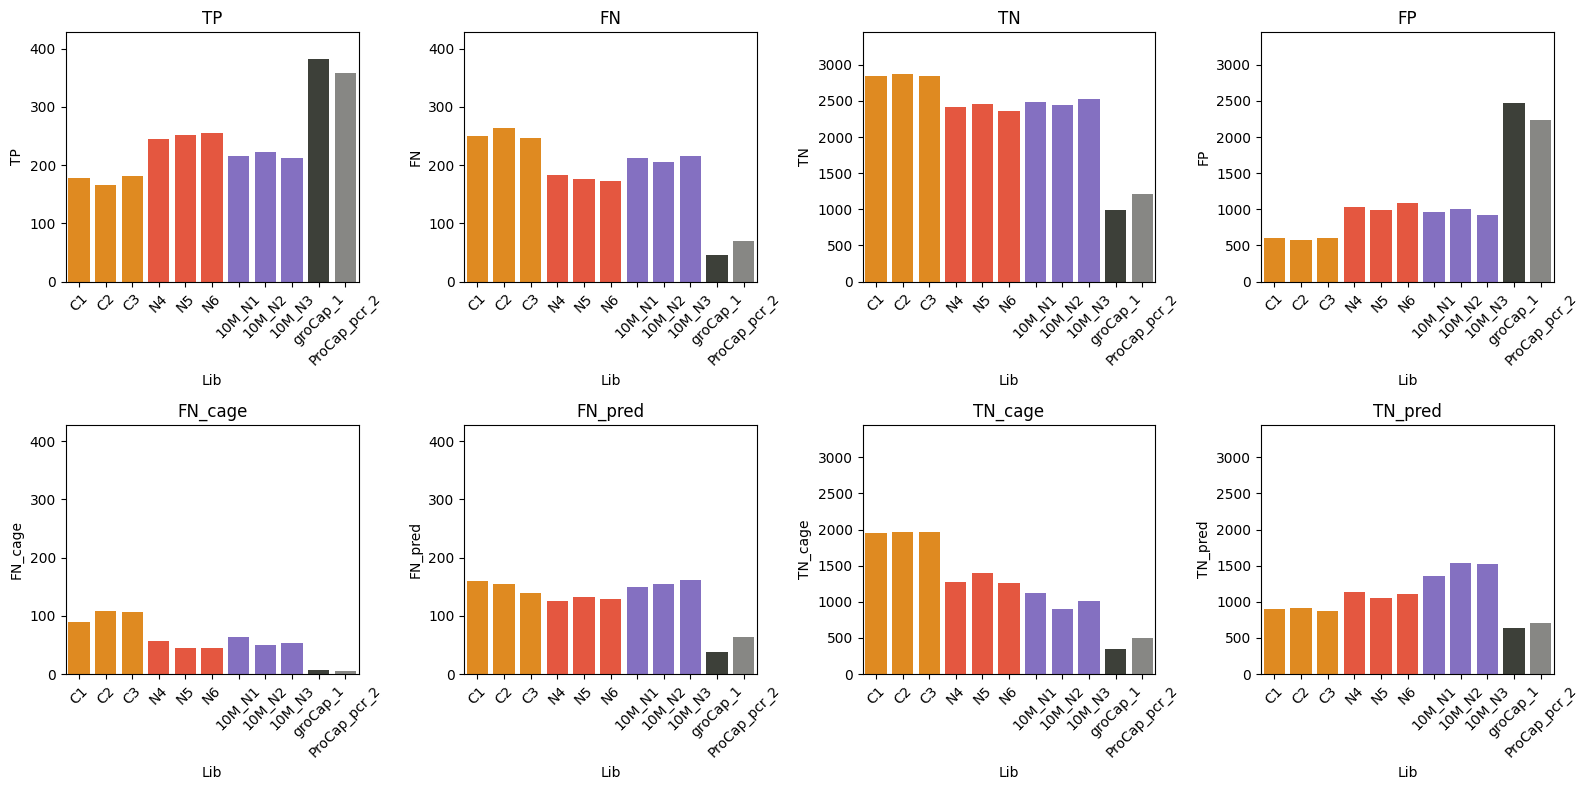

In [15]:
cfs_yproba_050, pr_yproba_050 = wrap_cfs_pr_plot(pos_scores[samples], neg_scores[samples], 0.5, P, N, colors, save='results/repSub_plot_cfs_050')

In [16]:
pr_yproba_050.transpose()

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
precision,0.228498,0.224185,0.230964,0.19261,0.202735,0.190157,0.182278,0.181744,0.187611,0.134433,0.138171
recall,0.415888,0.385514,0.425234,0.57243,0.588785,0.595794,0.504673,0.521028,0.495327,0.894860,0.836449


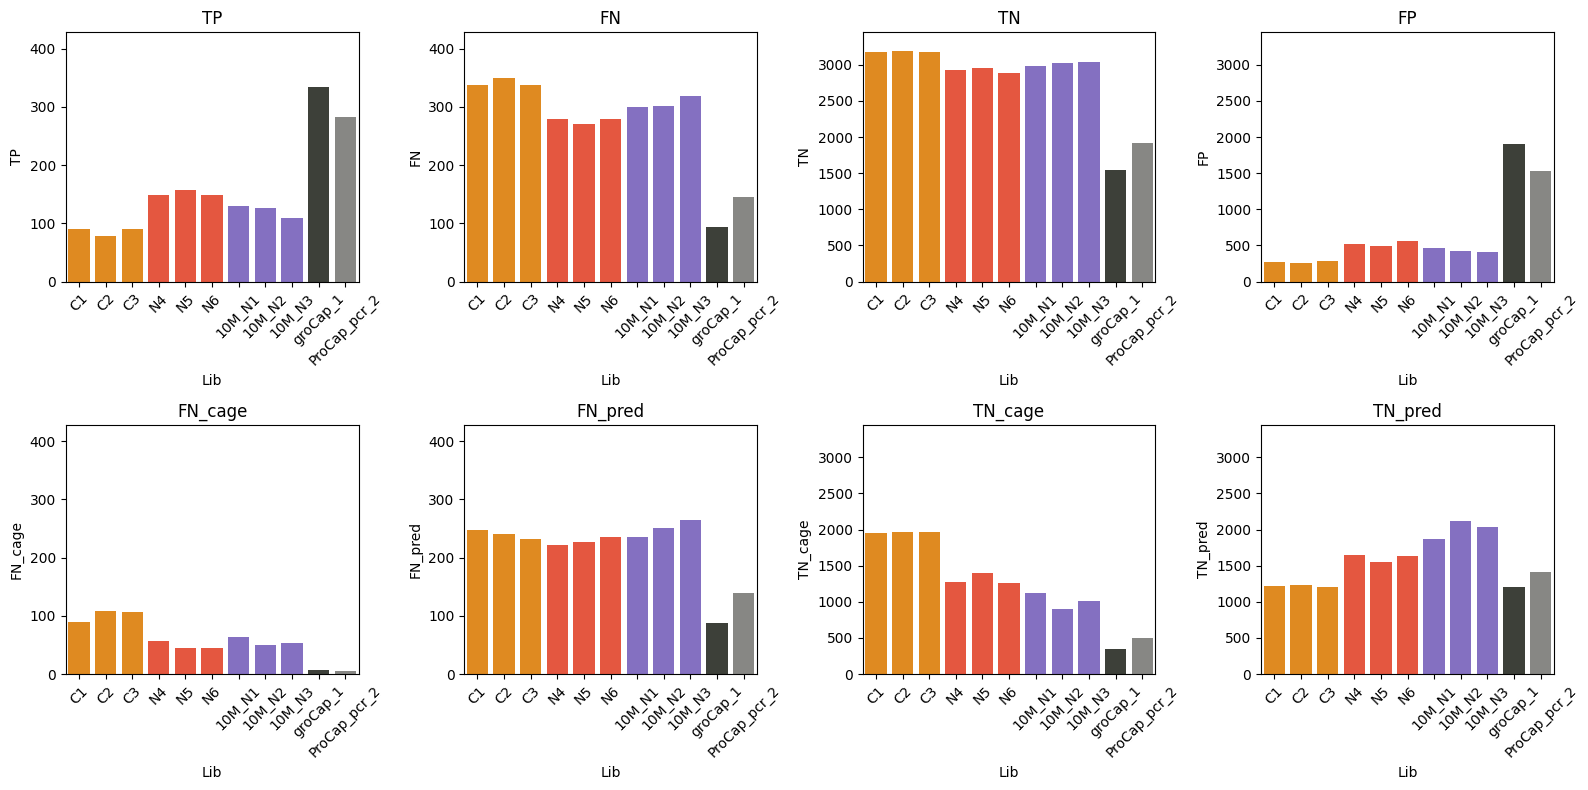

In [17]:
cfs_yproba_060, pr_yproba_060 = wrap_cfs_pr_plot(pos_scores[samples], neg_scores[samples], 0.6, P, N, colors, save='results/repSub_plot_cfs_060')

In [18]:
pr_yproba_060.transpose()

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
precision,0.246612,0.233038,0.243902,0.222388,0.239329,0.210452,0.218644,0.232176,0.210325,0.149575,0.155201
recall,0.212617,0.184579,0.210280,0.348131,0.366822,0.348131,0.301402,0.296729,0.257009,0.780374,0.658879


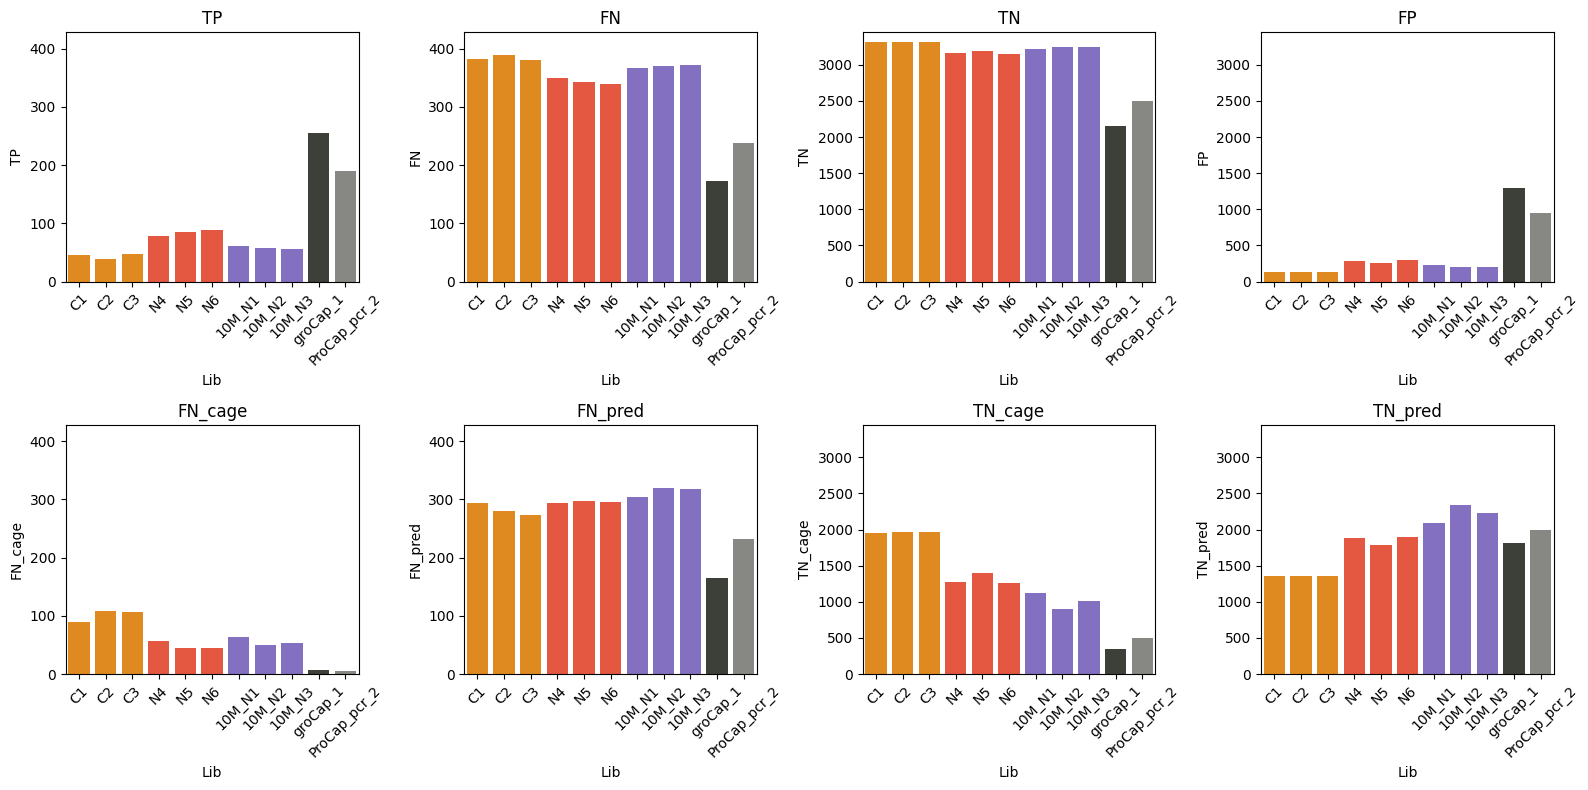

In [19]:
cfs_yproba_070, pr_yproba_070 = wrap_cfs_pr_plot(pos_scores[samples], neg_scores[samples], 0.7, P, N, colors, save='results/repSub_plot_cfs_070')

In [20]:
pr_yproba_070.transpose()

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
precision,0.248619,0.230769,0.271186,0.216667,0.251462,0.226804,0.205387,0.219697,0.212928,0.165055,0.166667
recall,0.105140,0.091121,0.112150,0.182243,0.200935,0.205607,0.142523,0.135514,0.130841,0.598131,0.443925


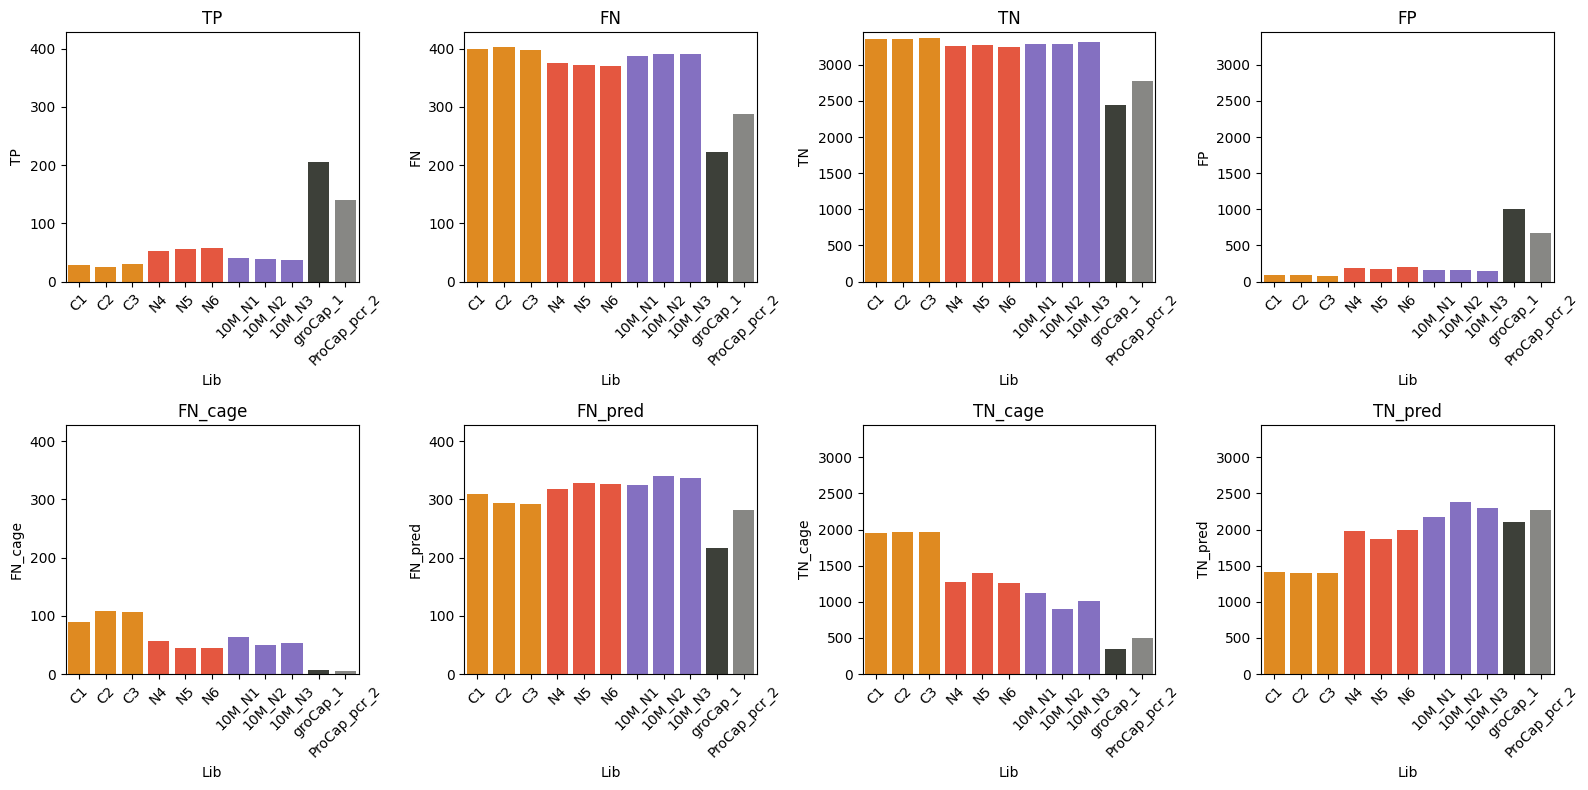

In [21]:
cfs_yproba_075, pr_yproba_075 = wrap_cfs_pr_plot(pos_scores[samples], neg_scores[samples], 0.75, P, N, colors, save='results/repSub_plot_cfs_075')

In [22]:
pr_yproba_075.transpose()

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
precision,0.243697,0.221239,0.265487,0.220833,0.247788,0.223529,0.202970,0.195876,0.209040,0.170124,0.173053
recall,0.067757,0.058411,0.070093,0.123832,0.130841,0.133178,0.095794,0.088785,0.086449,0.478972,0.327103


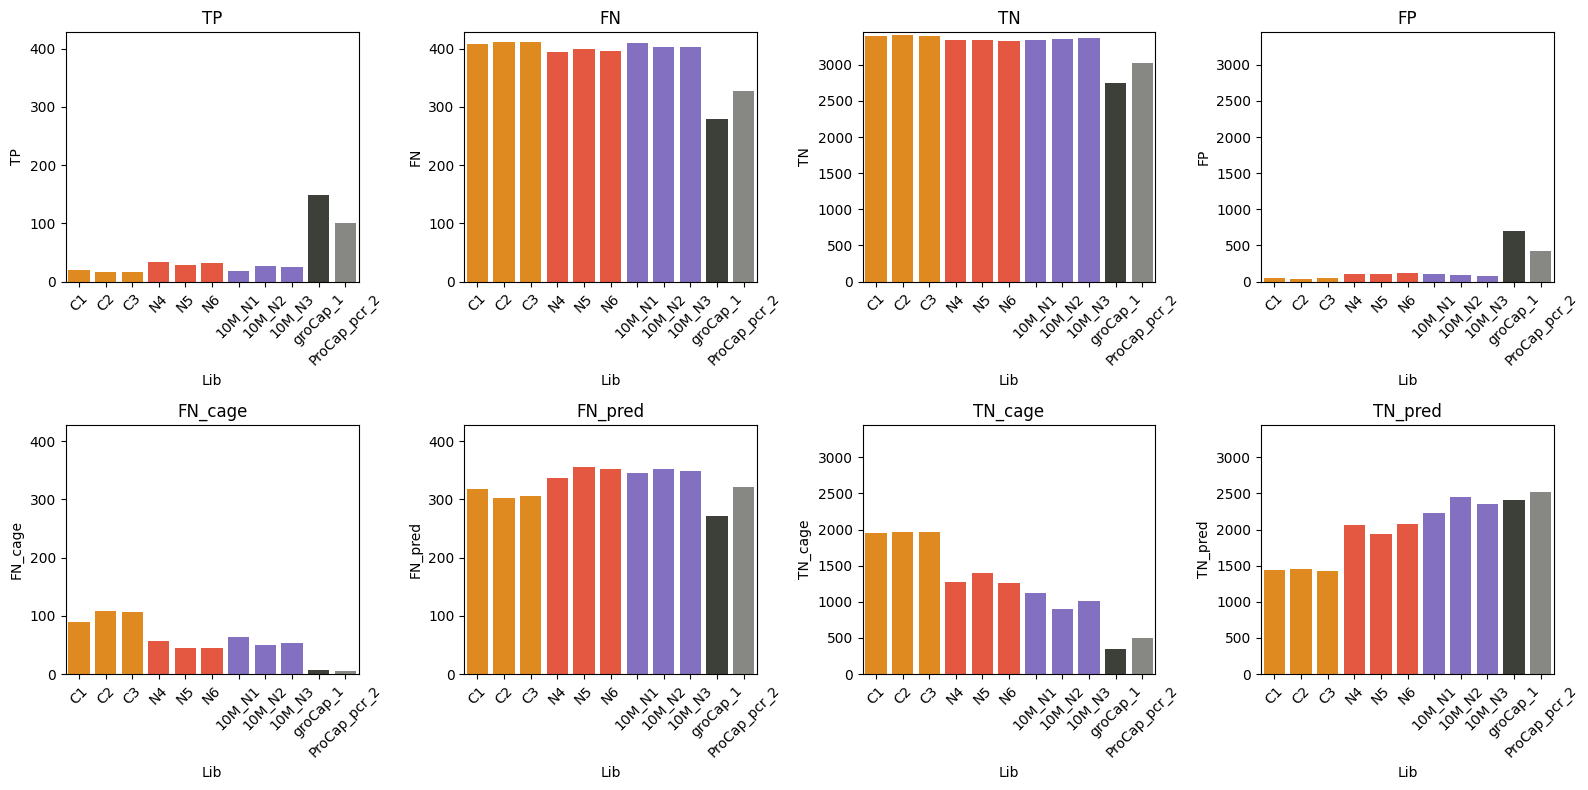

In [23]:
cfs_yproba_080, pr_yproba_080 = wrap_cfs_pr_plot(pos_scores[samples], neg_scores[samples], 0.8, P, N, colors, save='results/repSub_plot_cfs_080')

In [24]:
pr_yproba_080.transpose()

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
precision,0.270270,0.303571,0.246377,0.241135,0.212121,0.213333,0.153226,0.216667,0.229358,0.175915,0.190566
recall,0.046729,0.039720,0.039720,0.079439,0.065421,0.074766,0.044393,0.060748,0.058411,0.348131,0.235981


In [25]:
#### ROC AND AUCROC ###

In [26]:
def plot_roc_df(y_true, y_proba, samples, colors, save=False):
    plt.figure(figsize=(10, 5))
    y_proba = y_proba.fillna(0)  # Replace NaN values with 0

    for i in samples:
        fpr, tpr, _ = roc_curve(y_true, y_proba[i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{i} (AUC = {roc_auc:.2f})', color=colors.get(i, 'blue'))
        
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend()
    if save:
        plt.savefig(save + '.pdf')
    plt.show()


In [27]:
# Plot PR Curve
def plot_pr_curve(y_true, y_proba, samples, colors, save=False):
    plt.figure(figsize=(10, 5))
    y_proba = y_proba.fillna(0)  # Replace NaN values with 0

    for i in samples:
        precision, recall, _ = precision_recall_curve(y_true, y_proba[i])
        average_precision = average_precision_score(y_true, y_proba[i])
        plt.plot(recall, precision, label=f'{i} (AP = {average_precision:.2f})', color=colors.get(i, 'blue'))
        
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()
    if save:
        plt.savefig(save + '.pdf')
    plt.show()

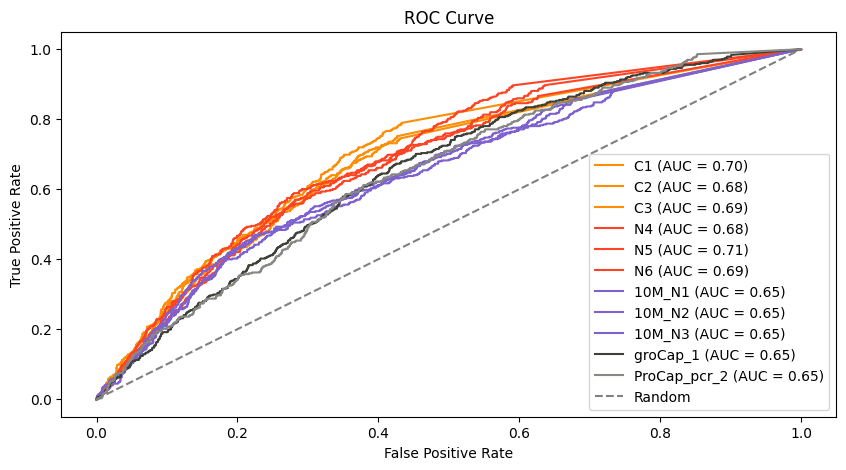

In [28]:
combined_df = pd.concat([pos_scores, neg_scores])
combined_df = combined_df.reset_index(drop=True)

y_true = combined_df["y_true"]
y_proba = combined_df[samples]

plot_roc_df(y_true, y_proba, samples, colors, save='results/repSub_plot_roc')

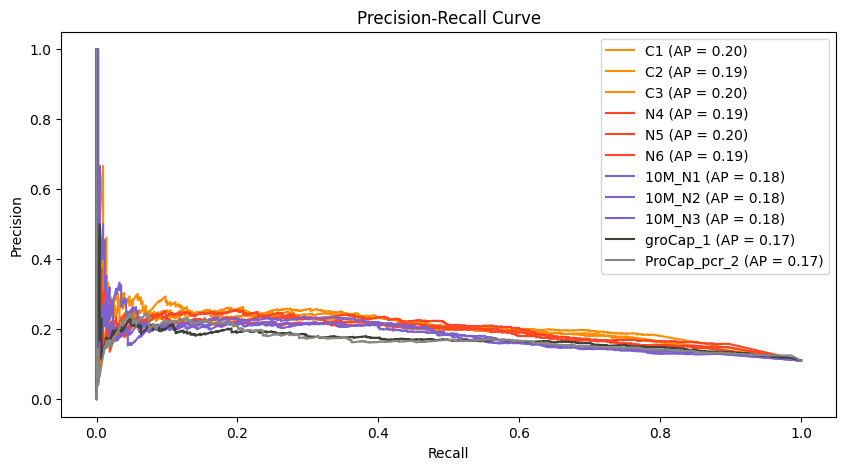

In [29]:
plot_pr_curve(y_true, y_proba, samples, colors, save='results/repSub_plot_pr')

In [ ]:
# plot comparison between reference on cage signal and prediction

all_t = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]
all_t_str = [str(element) for element in all_t]
precision = []
recall = []
for t in all_t:
    pr = wrap_pr(pos_scores[samples], neg_scores[samples], t, P, N)
    precision.append(list(pr['precision']))
    recall.append(pr['recall'])

In [61]:
precision_df = pd.DataFrame(precision, columns=samples, index=all_t_str)
precision_df

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
0.1,0.184196,0.176438,0.178690,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.15,0.184196,0.176438,0.178690,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.2,0.184196,0.176438,0.178690,0.146121,0.158025,0.148953,0.135486,0.129363,0.132812,0.119048,0.125371
0.25,0.184196,0.176438,0.178889,0.146121,0.158155,0.148680,0.134994,0.129363,0.132812,0.118798,0.124851
0.3,0.184052,0.176536,0.178988,0.146467,0.158264,0.148638,0.134723,0.129154,0.132693,0.118966,0.124700
0.35,0.184283,0.176273,0.178592,0.145924,0.157563,0.148760,0.135900,0.128932,0.133501,0.119313,0.125190
0.4,0.190330,0.185390,0.183560,0.150435,0.163357,0.152506,0.138087,0.129728,0.135167,0.121418,0.126286
0.45,0.200156,0.193244,0.193925,0.164981,0.168662,0.161910,0.147352,0.151332,0.151626,0.125589,0.130494
0.5,0.228498,0.224185,0.230964,0.192610,0.202735,0.190157,0.182278,0.181744,0.187611,0.134433,0.138171
0.55,0.242775,0.235294,0.254237,0.214208,0.224099,0.204124,0.208029,0.215517,0.209091,0.141394,0.147675


In [62]:
recall_df = pd.DataFrame(recall, columns=samples, index=all_t_str)
recall_df

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
0.1,0.789720,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.15,0.789720,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.2,0.789720,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.981308,0.985981
0.25,0.789720,0.745327,0.752336,0.866822,0.897196,0.894860,0.848131,0.883178,0.873832,0.978972,0.978972
0.3,0.787383,0.745327,0.752336,0.866822,0.894860,0.892523,0.845794,0.880841,0.871495,0.978972,0.971963
0.35,0.778037,0.735981,0.740654,0.857477,0.876168,0.883178,0.841121,0.871495,0.866822,0.974299,0.962617
0.4,0.726636,0.705607,0.693925,0.808411,0.845794,0.838785,0.782710,0.801402,0.803738,0.960280,0.946262
0.45,0.600467,0.574766,0.581776,0.724299,0.724299,0.728972,0.656542,0.703271,0.675234,0.934579,0.901869
0.5,0.415888,0.385514,0.425234,0.572430,0.588785,0.595794,0.504673,0.521028,0.495327,0.894860,0.836449
0.55,0.294393,0.271028,0.315421,0.457944,0.464953,0.462617,0.399533,0.408879,0.376168,0.838785,0.757009


In [63]:
# Transform all columns except 'y_true'
pos_cage_plot = pos_scores.copy()
pos_cage_plot.loc[:, pos_cage_plot.columns != 'y_true'] = pos_cage_plot.loc[:, pos_cage_plot.columns != 'y_true'].notna().astype(int)

neg_cage_plot = neg_scores.copy()
neg_cage_plot.loc[:, neg_cage_plot.columns != 'y_true'] = neg_cage_plot.loc[:, neg_cage_plot.columns != 'y_true'].notna().astype(int)

In [64]:
precision_cage = []
recall_cage = []
for t in all_t:
    pr_cage= wrap_pr(pos_cage_plot[samples], neg_cage_plot[samples], t, P, N)
    precision_cage.append(list(pr_cage['precision']))
    recall_cage.append(pr_cage['recall'])

In [65]:
precision_cage_df = pd.DataFrame(precision_cage, columns=samples, index=all_t_str)
precision_cage_df

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
0.1,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.15,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.2,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.25,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.3,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.35,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.4,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.45,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.5,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297
0.55,0.184196,0.176438,0.17869,0.146006,0.158025,0.148953,0.135486,0.129363,0.132812,0.119297,0.125297


In [66]:
recall_cage_df = pd.DataFrame(recall_cage, columns=samples, index=all_t_str)
recall_cage_df

,C1,C2,C3,N4,N5,N6,10M_N1,10M_N2,10M_N3,groCap_1,ProCap_pcr_2
0.1,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.15,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.2,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.25,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.3,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.35,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.4,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.45,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.5,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981
0.55,0.78972,0.745327,0.752336,0.866822,0.897196,0.897196,0.852804,0.883178,0.873832,0.983645,0.985981


In [108]:
import matplotlib.pyplot as plt

def plot_metrics(ref_data, data, libraries, title, y_label):
    """
    Function to plot metrics (precision or recall) in a 5x3 grid of subplots.
    
    Parameters:
    - ref_data (DataFrame): Reference dataset.
    - data (DataFrame): Data to compare against reference.
    - libraries (list): List of column names (libraries).
    - title (str): Title for the entire plot.
    - y_label (str): Label for the y-axis.
    """
    rows, cols = 5, 3  # Define the grid layout
    x_values = ref_data.index  # Get x-axis values (e.g., thresholds)

    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easier iteration

    # Plot each library
    for i, col in enumerate(libraries):
        if i >= len(axes):
            break  # Prevent errors if there are more libraries than subplots

        # Plot the reference and data values
        axes[i].plot(x_values, ref_data[col], label='Reference', linestyle='--', marker='x', color='grey')
        axes[i].plot(x_values, data[col], label='Data', linestyle='-', marker='o', color='orange')
        axes[i].set_title(col)
        axes[i].legend()

        # Add tick labels only for subplots in the last row
        if i // cols == rows - 1:
            axes[i].tick_params(axis='x', rotation=90, labelsize=8)  # Rotate and resize labels
            axes[i].set_xlabel('Thresholds')  # X-axis label
        else:
            axes[i].tick_params(labelbottom=False)  # Hide x-tick labels for other rows

    # Hide unused subplots
    for j in range(len(libraries), len(axes)):
        fig.delaxes(axes[j])  # Delete extra axes

    # Add shared y-label and title
    fig.text(0.04, 0.5, y_label, va='center', rotation='vertical')
    fig.suptitle(title, fontsize=16)

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to fit title
    plt.show()

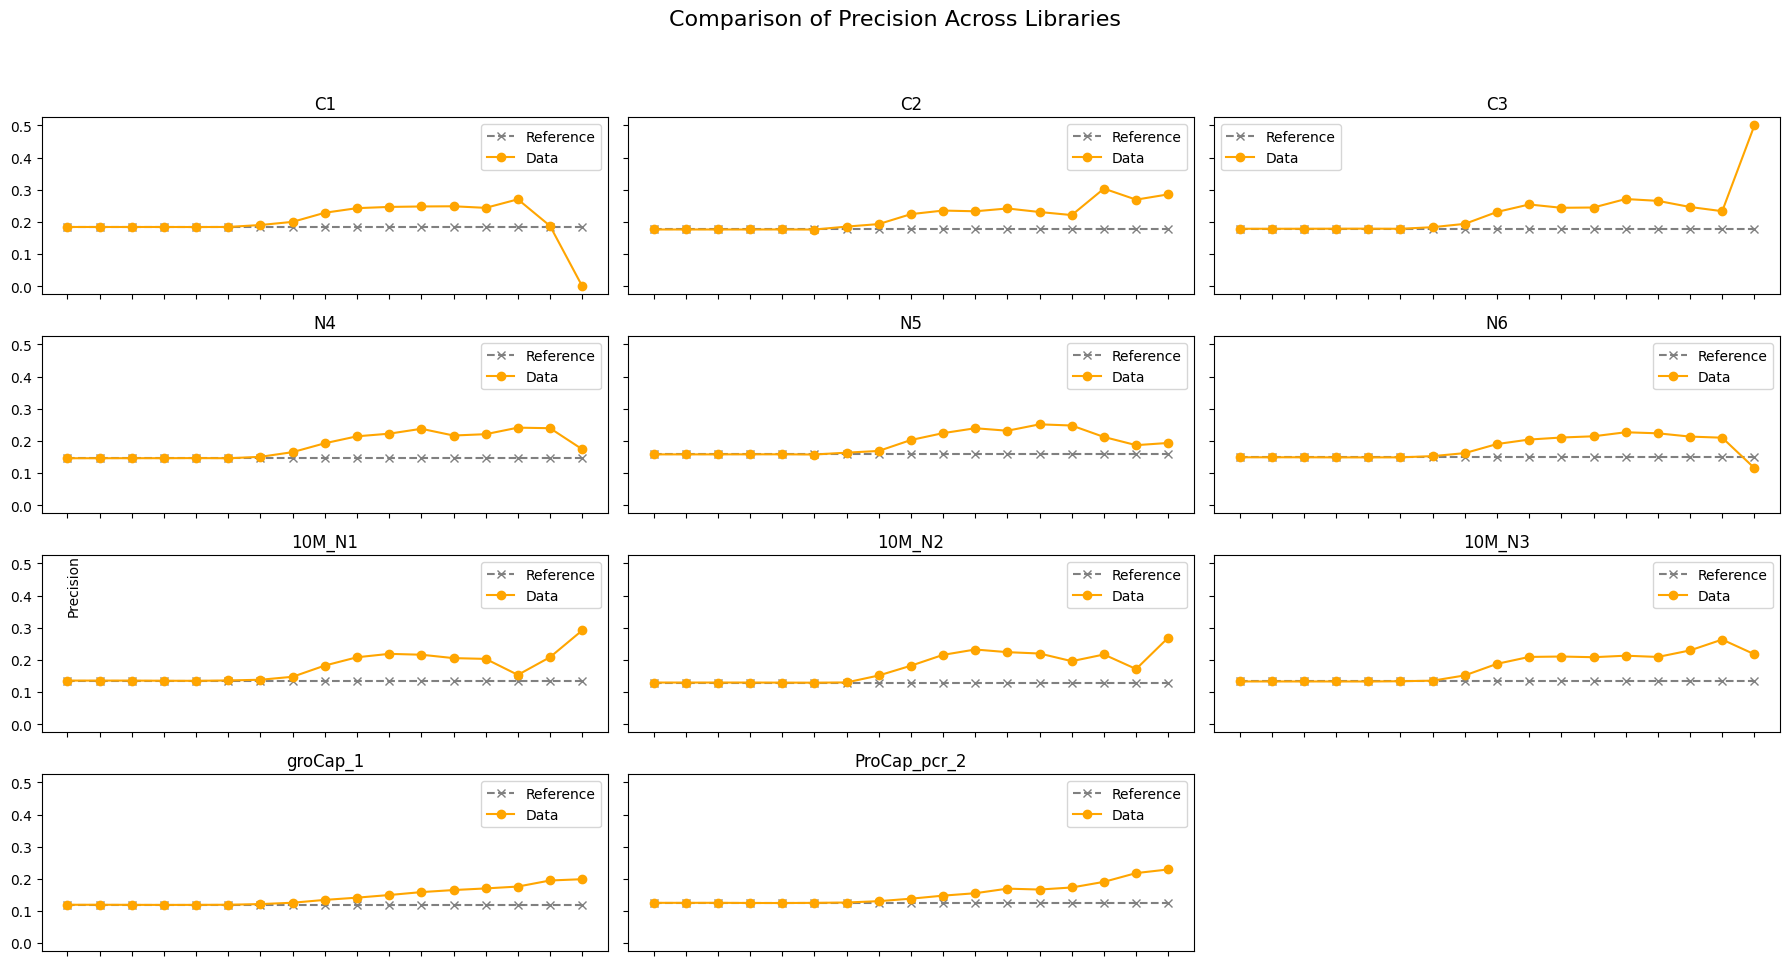

In [109]:
# Plot Precision
plot_metrics(
    ref_data=precision_cage_df,
    data=precision_df,
    libraries=samples,
    title='Comparison of Precision Across Libraries',
    y_label='Precision'
)

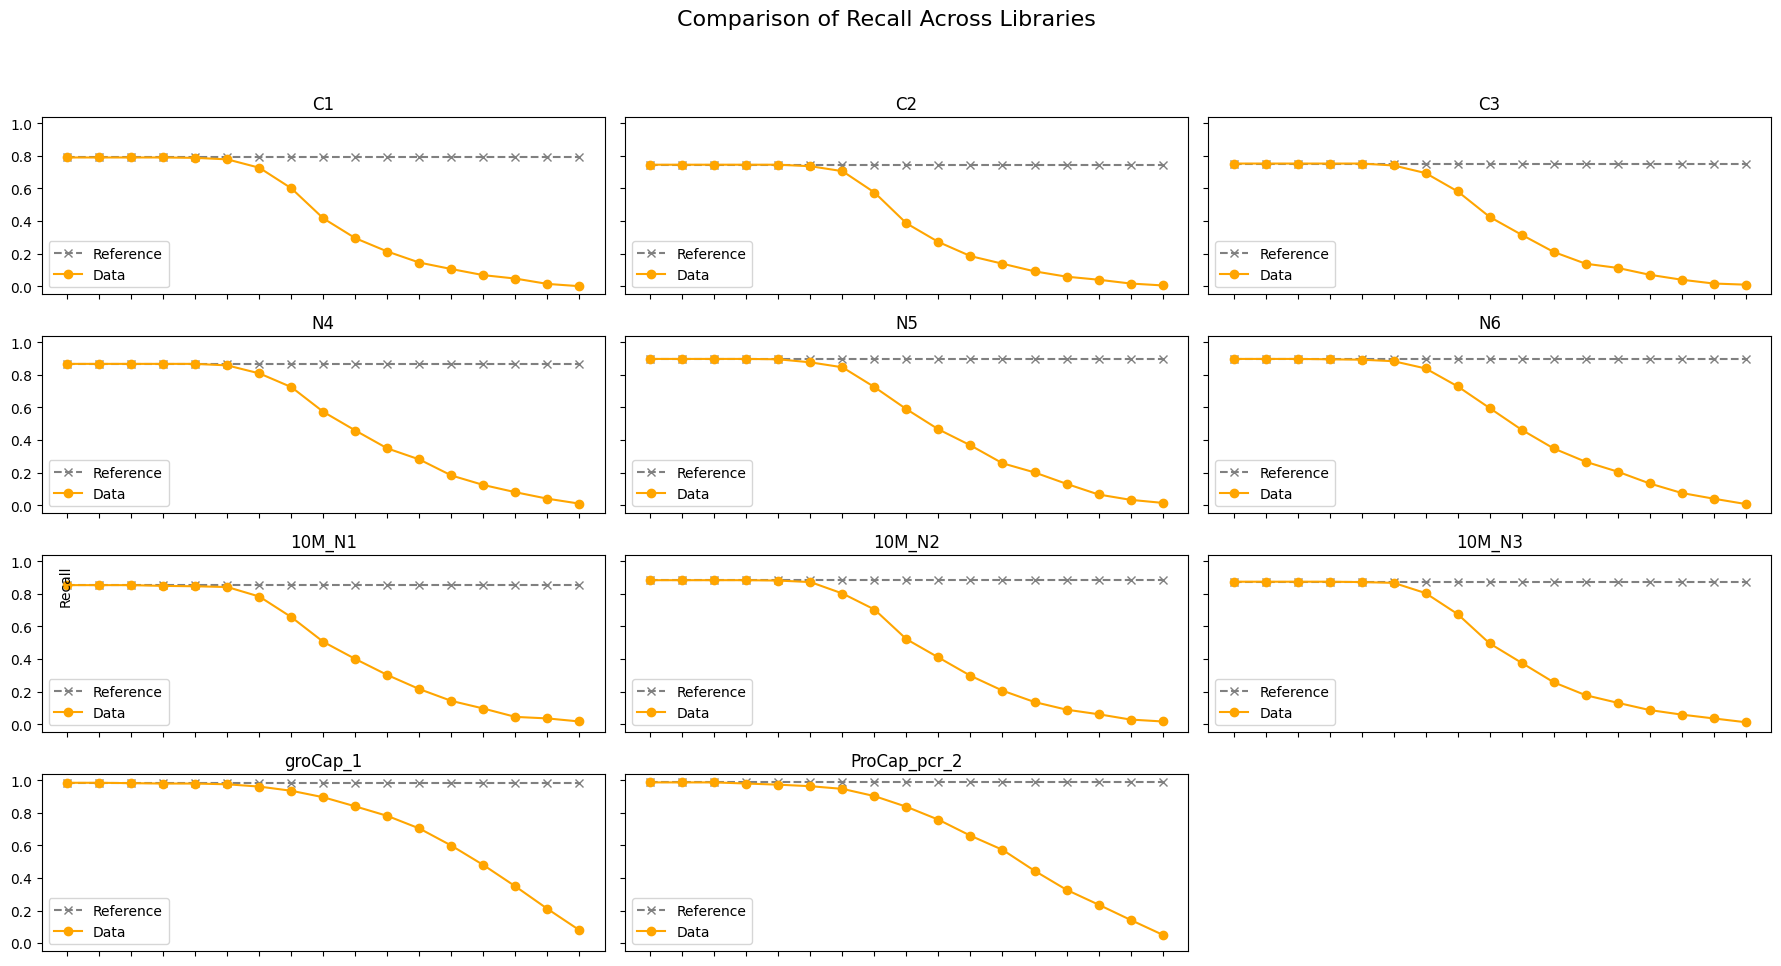

In [ ]:
# Plot Recall
plot_metrics(
    ref_data=recall_cage_df,
    data=recall_df,
    libraries=samples,
    title='Comparison of Recall Across Libraries',
    y_label='Recall'
)

In [111]:
import matplotlib.pyplot as plt

def plot_metric_comparison(ref_data, data, libraries, metric_name):
    """
    Plot metric comparison (Precision/Recall) for all indices in a 5x4 grid.

    Parameters:
    - ref_data (DataFrame): Reference dataset.
    - data (DataFrame): Data to compare against reference.
    - libraries (list): List of column names (libraries).
    - metric_name (str): Name of the metric (e.g., "Precision" or "Recall").
    """
    all_indices = ref_data.index  # Get all indices
    rows, cols = 4, 4  # Define the grid layout

    # Create subplots
    fig, axes = plt.subplots(rows, cols, figsize=(18, 12), sharex=True, sharey=True)
    axes = axes.flatten()  # Flatten the 2D array of axes for easier iteration

    # Plot each index in its own subplot
    for i, idx in enumerate(all_indices):
        if i >= len(axes):
            break  # Prevent errors if there are more indices than subplots

        ref_row = ref_data.loc[idx]
        data_row = data.loc[idx]

        # Plot markers without connecting lines
        axes[i].plot(libraries, ref_row, label='Reference', linestyle='', marker='x', color='grey')
        axes[i].plot(libraries, data_row, label='Data', linestyle='', marker='o', color='orange')
        axes[i].set_title(f'Index: {idx}')
        axes[i].legend()
        axes[i].tick_params(axis='x', rotation=90)  # Rotate x-axis labels for readability

    # Hide unused subplots
    for j in range(len(all_indices), len(axes)):
        fig.delaxes(axes[j])  # Delete extra axes

    # Add shared labels and title
    fig.text(0.04, 0.5, metric_name, va='center', rotation='vertical')  # Add shared y-axis label
    fig.suptitle(f'Comparison of {metric_name} Across Libraries', fontsize=16)  # Add figure title

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])  # Reserve space for the title
    plt.show()


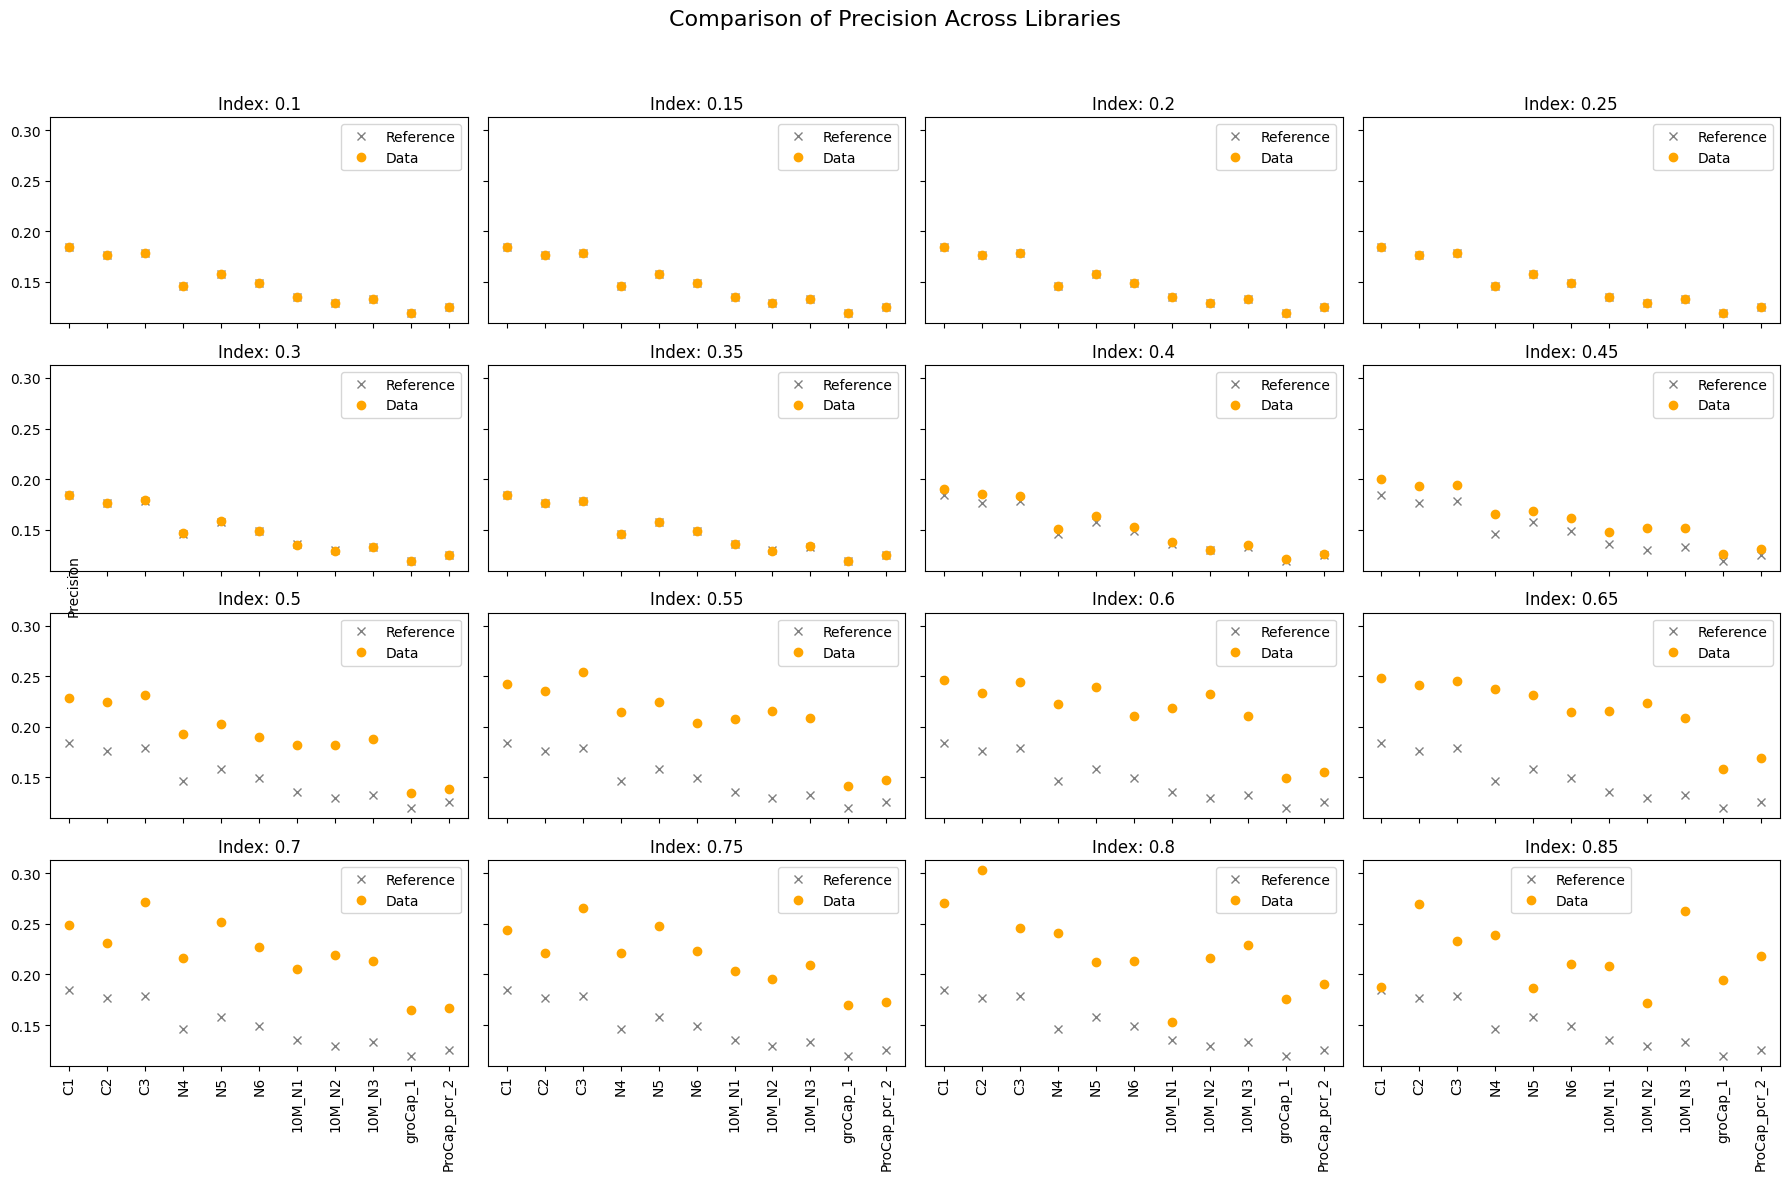

In [112]:
# Plot Precision
plot_metric_comparison(
    ref_data=precision_cage_df,
    data=precision_df,
    libraries=samples,
    metric_name="Precision"
)

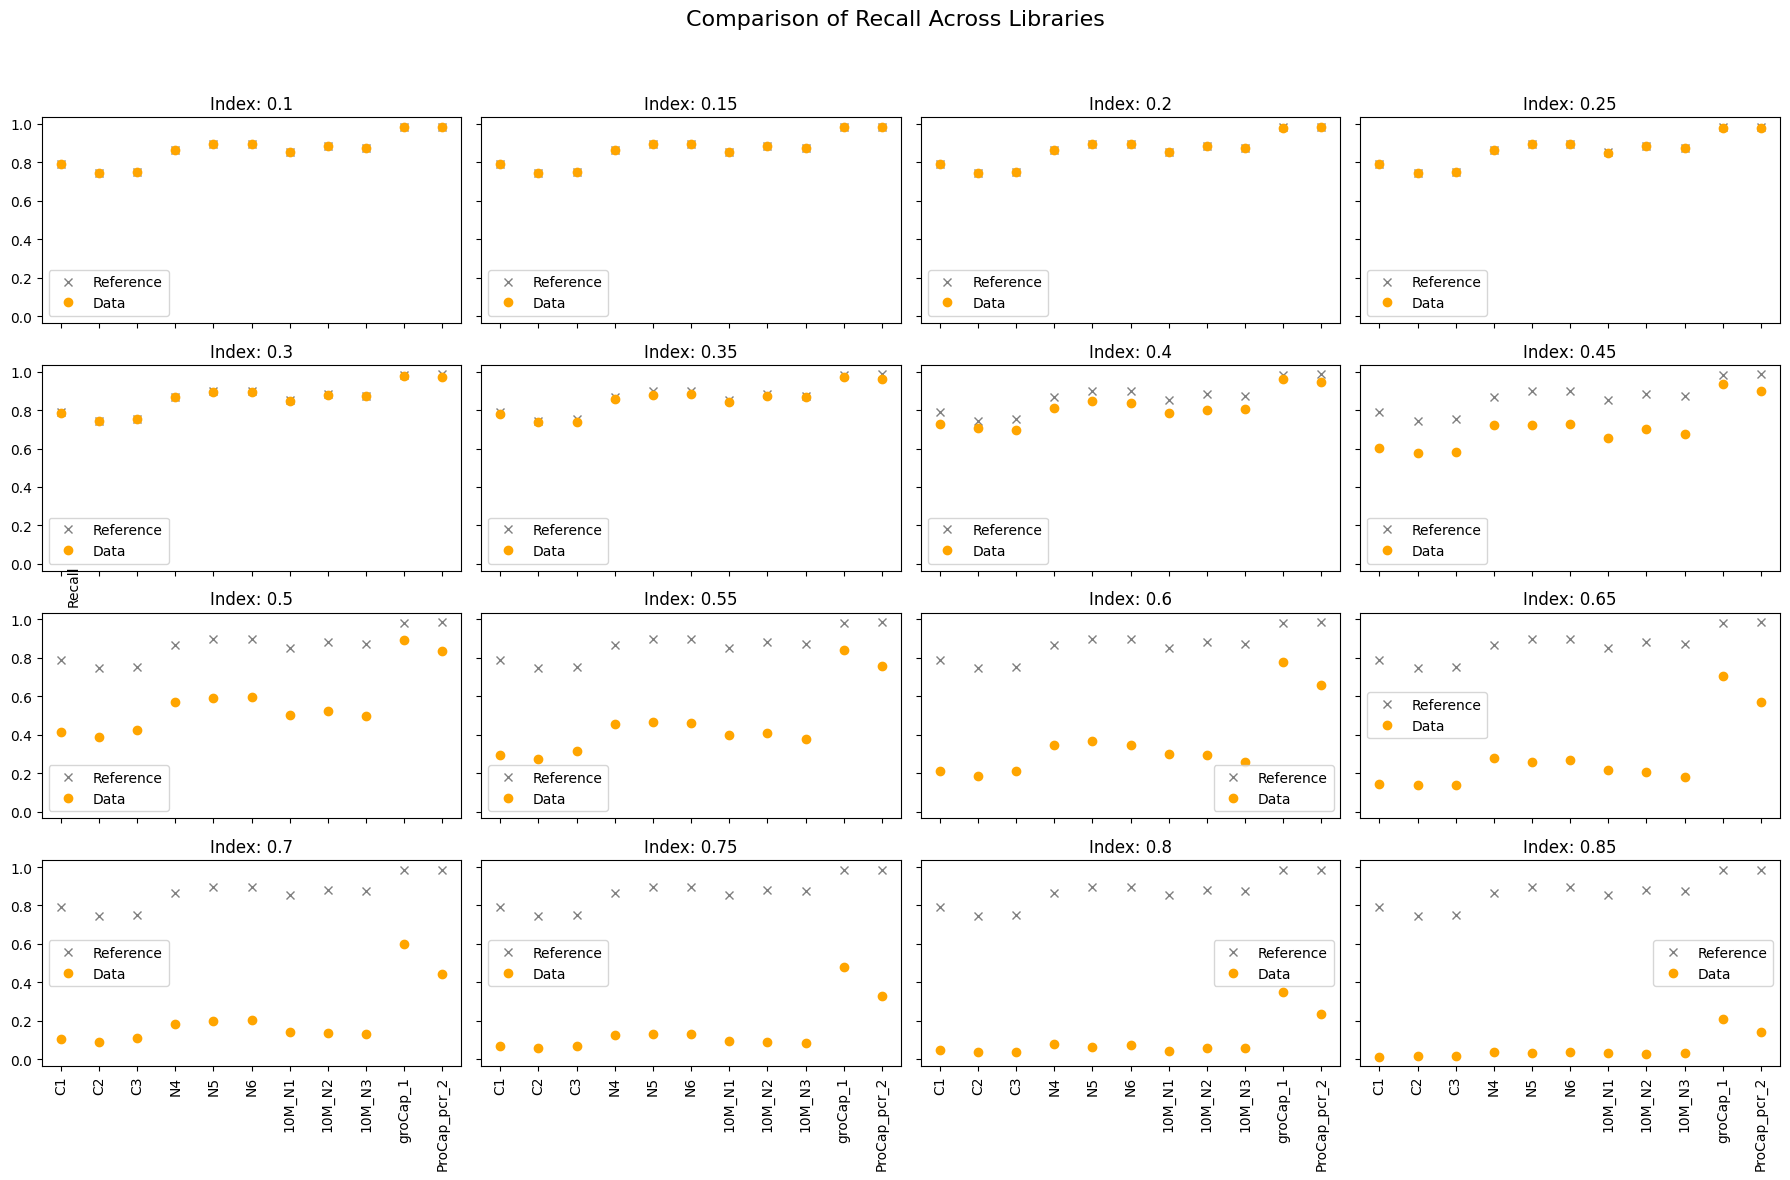

In [113]:
# Plot Recall
plot_metric_comparison(
    ref_data=recall_cage_df,
    data=recall_df,
    libraries=samples,
    metric_name="Recall"
)